# NB-2 — From kernels to Gaussian processes

**Roadmap:** `resources/topics_guide.md`, Part 2.

**What changes here.** In NB-1 the kernel $k(x,x')$ measured *similarity* and we got back a single line. Here the identical object is a *covariance* and we get back a whole distribution over functions. Nothing about the kernel changes — only what we do with it. Concretely, NB-1's regulariser $\lVert w\rVert^2_{\mathcal H}$ becomes a log prior and the hinge loss becomes a Gaussian log likelihood. This notebook is where the roadmap stops being about classifiers and starts being about uncertainty.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Define a **Gaussian process** and draw functions from a prior specified only by a kernel.
- Show empirically that the kernel *is* the covariance of those draws.
- Apply the **conditioning formula** from NB-0 §0.6 to get a posterior mean and credible band.
- Implement GP regression stably with a **Cholesky factor**, and say why forming $K^{-1}$ is wrong.
- Explain why a GP posterior mean has the same **representer form** as an SVM but no sparsity.
- Use an **ARD** kernel to let the data decide which inputs matter.
- Recognise where ARD fails — two exchangeable proxies — and why that failure is about the design, not the algorithm.
- Fit hyperparameters by **Type-II maximum likelihood** and explain the built-in Occam penalty.
- Verify an analytic gradient before trusting an optimiser.
- Scale to large $n$ with **inducing points**, and use the variational bound to choose how many.

## What should already be familiar?

You need NB-0 §0.6 (the Gaussian conditioning formula), §0.2 (Cholesky and jitter) and §0.3 (log-determinants) — this notebook is largely those three facts applied to a kernel. From NB-1 you need the idea of a kernel and the representer form $f(x) = \sum_i \alpha_i k(x_i, x)$.

You do not need to have met Gaussian processes, marginal likelihoods, or variational bounds before. NumPy, SciPy and Matplotlib only. Allow about ninety minutes; §2.4 is the densest part.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 2.1 | What does a distribution over functions look like? | Prior draws, and the kernel recovered as their covariance |
| 2.2 | How do we get from a prior to a prediction? | A GP class, checked against brute-force conditioning |
| 2.3 | Can the kernel decide which exposures matter? | ARD relevances, and the case where they mislead |
| 2.4 | How do we choose hyperparameters without cross-validation? | Type-II MLE with a verified analytic gradient |
| 2.5 | What do we do when $n$ is too large? | A sparse GP and a bound that says when to stop |

§2.2 is the section everything else depends on. If you only have time for one, make it that one, and make sure you can say what each term in the boxed formula does.

Seven **Try it** boxes ask for an answer in your own words. Several of them ask you to *predict before running* — that is deliberate, and worth doing honestly.

In [1]:
import numpy as np
import nbkit as nk
from scipy.optimize import minimize

plt = nk.set_style()
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

---
## 2.1 What does a distribution over functions look like?

A **Gaussian process** is a distribution over functions such that any finite set of
function values is jointly Gaussian:

$$
f \sim \mathcal{GP}\big(m(\cdot),\, k(\cdot,\cdot)\big)
\quad\Longleftrightarrow\quad
\big(f(x_1),\dots,f(x_n)\big) \sim \mathcal{N}\big(m(X),\, K_{XX}\big).
$$

That is the entire definition. The mean function $m$ is usually taken as $0$ (after
centring $y$), so **the kernel is the model**: it alone determines what functions are
considered plausible before seeing data.

To sample: build $K$, Cholesky it, and push standard normals through
$f = L\varepsilon$, since $\operatorname{Cov}(L\varepsilon) = LL^\top = K$.

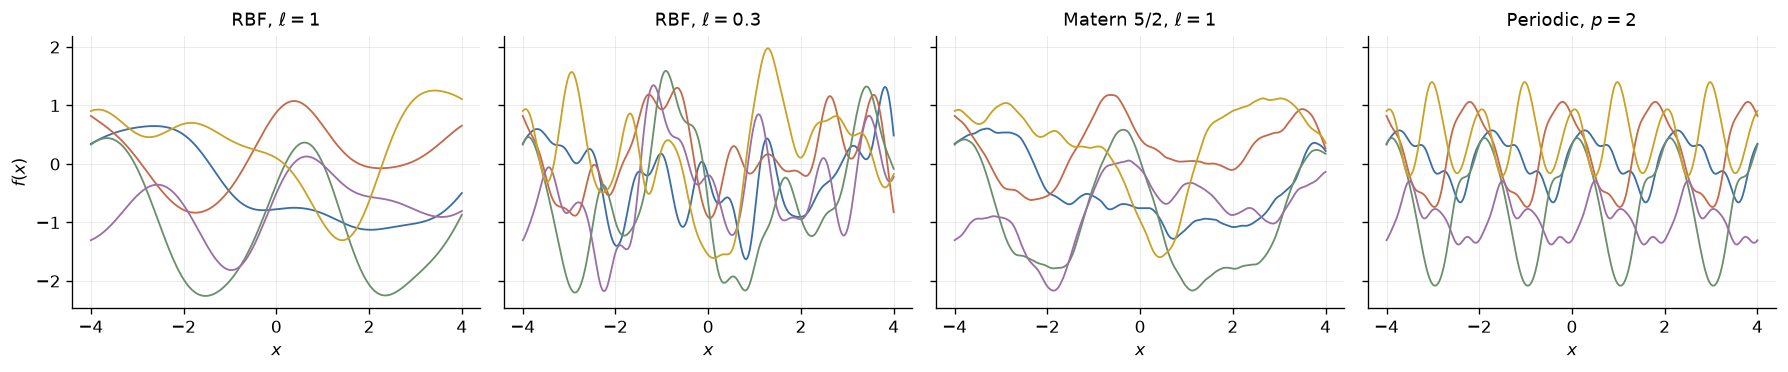

In [2]:
def sample_gp_prior(kernel, X, n_samples=5, seed=0, **kw):
    """Draw functions from a zero-mean GP prior at the locations X."""
    r = np.random.default_rng(seed)
    K = nk.gram(kernel, X, **kw)
    L, _ = nk.jitter_chol(K)
    return (L @ r.normal(size=(len(X), n_samples))).T          # (n_samples, n)


xs = np.linspace(-4, 4, 300)[:, None]

specs = [
    ("RBF, $\\ell=1$",       nk.rbf_kernel,      dict(lengthscale=1.0)),
    ("RBF, $\\ell=0.3$",     nk.rbf_kernel,      dict(lengthscale=0.3)),
    ("Matern 5/2, $\\ell=1$", nk.matern52_kernel, dict(lengthscale=1.0)),
    ("Periodic, $p=2$",     nk.periodic_kernel, dict(period=2.0, lengthscale=1.0)),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, (name, kf, kw) in zip(axes, specs):
    for f in sample_gp_prior(kf, xs, n_samples=5, seed=1, **kw):
        ax.plot(xs, f, lw=1.1)
    ax.set_title(name); ax.set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
plt.tight_layout(); plt.show()

Four kernels, four completely different notions of "a plausible function": smooth and
wiggly (RBF with short $\ell$), smooth and slow (long $\ell$), rougher (Matérn 5/2 is only
twice differentiable), and exactly repeating (periodic). **Choosing a kernel is choosing a
prior**, and in Part 3 we will choose them deliberately to encode what we know about
exposures.

### Try it 1. What have you assumed by picking a kernel?

The four panels show prior draws under an RBF at two lengthscales, a Matérn 5/2, and a periodic kernel. No data have been seen yet.

1. For each panel, describe in one phrase the kind of function it considers plausible.
2. You are modelling weekly air pollution across a year. Which of the four would you start from, and what would you have to add?
3. The Matérn 5/2 draws look visibly rougher than the RBF at the same lengthscale. What real property of an exposure–response curve would make you *want* that roughness?
4. Complete the sentence in your own words: "Choosing a kernel is choosing …"

**Your answer**

*(write here)*

max |empirical cov - K| = 0.0132
mean |.|                = 0.00397
empirical mean ~ 0      : max |mean| = 0.0096


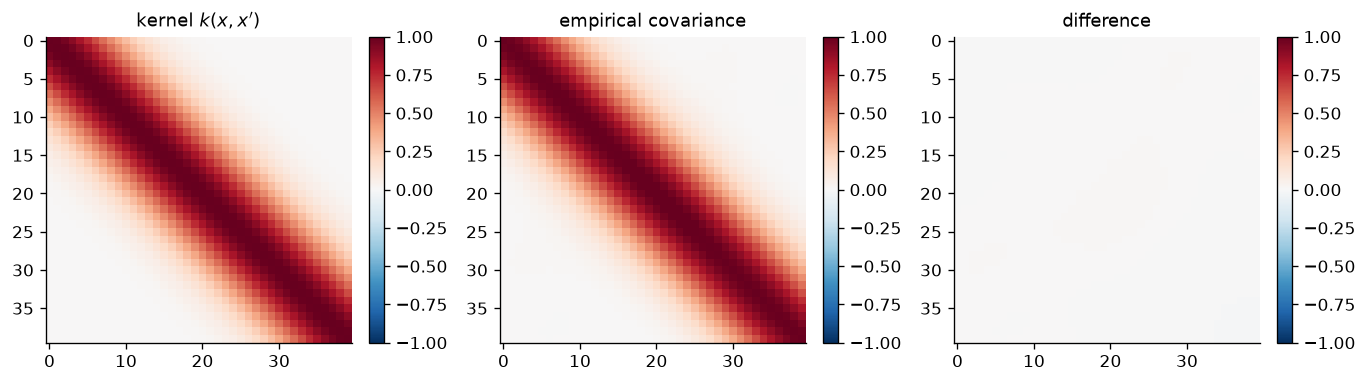

In [3]:
# The kernel *is* the covariance: verify empirically from many prior draws.
xs_small = np.linspace(-3, 3, 40)[:, None]
draws = sample_gp_prior(nk.rbf_kernel, xs_small, n_samples=60_000, seed=3, lengthscale=1.0)

K_true = nk.gram(nk.rbf_kernel, xs_small, lengthscale=1.0)
K_emp = np.cov(draws.T)

print(f"max |empirical cov - K| = {np.abs(K_emp - K_true).max():.4f}")
print(f"mean |.|                = {np.abs(K_emp - K_true).mean():.5f}")
print(f"empirical mean ~ 0      : max |mean| = {np.abs(draws.mean(0)).max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
for ax, M, t in [(axes[0], K_true, "kernel $k(x,x')$"),
                 (axes[1], K_emp, "empirical covariance"),
                 (axes[2], K_emp - K_true, "difference")]:
    im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(t); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

---
## 2.2 How do we get from a prior to a prediction?

This is §0.6 with the covariance supplied by a kernel. With noisy observations
$y = f(X) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,\sigma_n^2 I)$, the joint of
observed $y$ and test values $f_*$ is Gaussian, so

$$
\boxed{
\begin{aligned}
\bar{f}_* &= K_{*X}\,\big[K_{XX} + \sigma_n^2 I\big]^{-1} y \\
\operatorname{Cov}(f_*) &= K_{**} - K_{*X}\big[K_{XX} + \sigma_n^2 I\big]^{-1}K_{X*}
\end{aligned}}
$$

**Never** form the inverse. Use the Cholesky $L$ of $K_{XX}+\sigma_n^2 I$:

$$
\alpha = L^{-\top}(L^{-1}y), \qquad
\bar f_* = K_{*X}\alpha, \qquad
V = L^{-1}K_{X*}, \qquad
\operatorname{Cov}(f_*) = K_{**} - V^\top V .
$$

This is $O(n^3)$ once, then $O(n)$ per prediction — and it is numerically stable, which the
explicit inverse is not. The log marginal likelihood falls out of the same $L$, which is
why 2.4 is nearly free once this is written.

In [4]:
class GP:
    """Exact GP regression with a Gaussian likelihood (Rasmussen & Williams Alg. 2.1)."""

    def __init__(self, kernel, noise=0.1, **kw):
        self.kernel, self.noise, self.kw = kernel, noise, kw

    def fit(self, X, y):
        self.X_ = np.atleast_2d(X)
        self.y_mean_ = y.mean()
        self.y_ = y - self.y_mean_                       # zero-mean GP => centre y
        K = nk.gram(self.kernel, self.X_, **self.kw) + self.noise**2 * np.eye(len(self.X_))
        self.L_, _ = nk.jitter_chol(K)
        # alpha = (K + s^2 I)^-1 y, via two triangular solves
        self.alpha_ = np.linalg.solve(self.L_.T, np.linalg.solve(self.L_, self.y_))
        return self

    def predict(self, Xs, return_cov=False):
        Xs = np.atleast_2d(Xs)
        Ks = self.kernel(self.X_, Xs, **self.kw)                     # (n, m)
        mu = Ks.T @ self.alpha_ + self.y_mean_
        V = np.linalg.solve(self.L_, Ks)                             # (n, m)
        if return_cov:
            Kss = nk.gram(self.kernel, Xs, **self.kw)
            return mu, Kss - V.T @ V
        Kss_diag = np.diag(self.kernel(Xs, Xs, **self.kw)).copy()
        var = np.maximum(Kss_diag - np.sum(V**2, 0), 0.0)
        return mu, var                                               # variance of f (noise-free)

    def log_marginal_likelihood(self):
        """log p(y | X, theta) = -1/2 y'K^-1 y - sum log L_ii - n/2 log 2pi   (see 2.4)."""
        n = len(self.y_)
        return float(-0.5 * self.y_ @ self.alpha_
                     - np.log(np.diag(self.L_)).sum()
                     - 0.5 * n * np.log(2 * np.pi))

    def sample_posterior(self, Xs, n_samples=5, seed=0):
        r = np.random.default_rng(seed)
        mu, cov = self.predict(Xs, return_cov=True)
        L, _ = nk.jitter_chol(cov)
        return mu[:, None].T + (L @ r.normal(size=(len(Xs), n_samples))).T

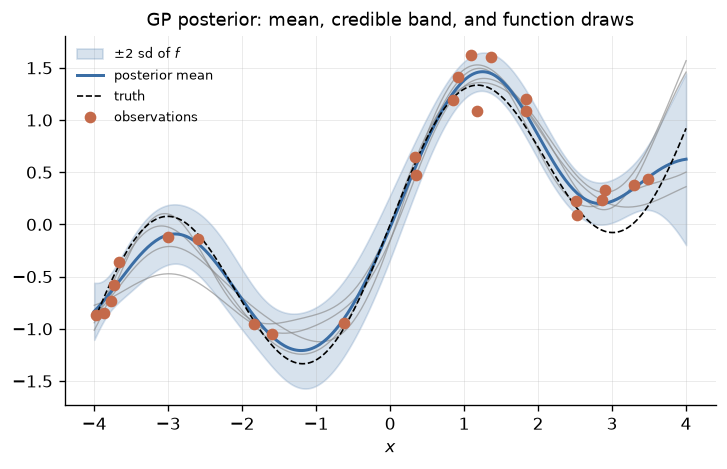

log marginal likelihood = -6.6776
RMSE vs truth on grid   = 0.1454


In [5]:
# Ground truth: a smooth function observed at scattered points with noise.
def f_true(x):
    return np.sin(1.5 * x) + 0.3 * x

n_tr, sigma_n = 25, 0.20
X_tr = np.sort(rng.uniform(-4, 4, n_tr))[:, None]
y_tr = f_true(X_tr).ravel() + sigma_n * rng.normal(size=n_tr)

gp = GP(nk.rbf_kernel, noise=sigma_n, lengthscale=1.0, variance=1.0).fit(X_tr, y_tr)
mu, var = gp.predict(xs)
sd = np.sqrt(var)

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(xs.ravel(), mu - 2*sd, mu + 2*sd, alpha=0.20,
                color=nk.PALETTE["band"], label="$\\pm2$ sd of $f$")
for s in gp.sample_posterior(xs, n_samples=4, seed=5):
    ax.plot(xs, s, lw=0.8, alpha=0.65, color=nk.PALETTE["muted"])
ax.plot(xs, mu, color=nk.PALETTE["pos"], lw=1.8, label="posterior mean")
ax.plot(xs, f_true(xs), "--", color="k", lw=1, label="truth")
ax.plot(X_tr, y_tr, "o", color=nk.PALETTE["neg"], ms=6, zorder=5, label="observations")
ax.legend(fontsize=8, loc="upper left"); ax.set_xlabel("$x$")
ax.set_title("GP posterior: mean, credible band, and function draws")
plt.show()

print(f"log marginal likelihood = {gp.log_marginal_likelihood():.4f}")
print(f"RMSE vs truth on grid   = {np.sqrt(np.mean((mu - f_true(xs).ravel())**2)):.4f}")

The band widens away from data and pinches at observations — and crucially the *individual
draws* are what a "credible interval on a function" actually means: the pointwise band
hides the fact that neighbouring values are strongly correlated.

### Try it 2. What does the shaded band actually mean?

The figure shows a pointwise $\pm 2$ sd band *and* four sampled functions.

1. The band is computed pointwise. Why is that not the same as "95% of true functions lie entirely inside it"?
2. Look at the individual draws. What do they show that the band hides?
3. The band pinches at observations but does not close completely. Which parameter controls how nearly it closes?
4. Predict, before scrolling: if you set the noise to zero, what happens to the band at the observed points — and what happens to the numerical stability? (NB-0 §0.2 is relevant.)

**Your answer**

*(write here)*

In [6]:
# Verify the closed form against brute-force conditioning of the joint Gaussian.
X_all = np.vstack([X_tr, xs[:5]])
K_all = nk.gram(nk.rbf_kernel, X_all, lengthscale=1.0, variance=1.0)
K_all[:n_tr, :n_tr] += sigma_n**2 * np.eye(n_tr)          # noise on observed block only

S11 = K_all[n_tr:, n_tr:]
S12 = K_all[n_tr:, :n_tr]
S22 = K_all[:n_tr, :n_tr]
y_c = y_tr - y_tr.mean()

brute_mu = S12 @ np.linalg.solve(S22, y_c) + y_tr.mean()
brute_cov = S11 - S12 @ np.linalg.solve(S22, S12.T)

gp_mu, gp_cov = gp.predict(xs[:5], return_cov=True)
print("max |mean  difference| :", np.abs(brute_mu - gp_mu).max())
print("max |cov   difference| :", np.abs(brute_cov - gp_cov).max())

max |mean  difference| : 1.3658495667812076e-08
max |cov   difference| : 3.5582431445746465e-09


### How is this different from the SVM?

Both are $\sum_i \alpha_i k(x_i, x)$ — the same representer form from 1.2. The difference is
how $\alpha$ is obtained: the SVM solves a constrained QP that drives most $\alpha_i$ to
exactly zero, while the GP solves a linear system that leaves all of them non-zero. The GP
buys uncertainty quantification at the price of sparsity.

In [7]:
print(f"GP:  all {len(gp.alpha_)} alphas non-zero, "
      f"min |alpha| = {np.abs(gp.alpha_).min():.4f}")
print(f"     posterior mean at x=0: {gp.predict(np.array([[0.0]]))[0][0]:+.4f}")
print(f"     = sum_i alpha_i k(x_i, 0) + ybar = "
      f"{gp.alpha_ @ nk.rbf_kernel(X_tr, np.array([[0.0]]), lengthscale=1.0).ravel() + y_tr.mean():+.4f}")

GP:  all 25 alphas non-zero, min |alpha| = 0.3202
     posterior mean at x=0: -0.0266
     = sum_i alpha_i k(x_i, 0) + ybar = -0.0266


### Try it 3. Same formula, different answer — why?

The GP posterior mean is $\sum_i \alpha_i k(x_i, x)$, exactly the SVM's decision function. But all 14 GP $\alpha$'s are non-zero, where the SVM had 2.

1. What is different about how the two $\alpha$ vectors are obtained?
2. The GP gives uncertainty; the SVM gives sparsity. Explain why you cannot have both for free.
3. For an exposome analysis with $n = 200$ subjects, which trade would you take, and why?

**Your answer**

*(write here)*

---
## 2.3 Can the kernel decide which exposures matter?

Give every input dimension its own lengthscale:

$$
k_{\text{ARD}}(x,x') = \sigma_f^2 \exp\!\Big(-\tfrac12 \sum_{j=1}^{d} \frac{(x_j - x'_j)^2}{\ell_j^2}\Big).
$$

If $\ell_j \to \infty$, dimension $j$ contributes nothing to the distance and the function
is **constant** in that input — the model has switched it off. Fitting $\{\ell_j\}$ by
maximising the marginal likelihood (2.4) therefore performs *soft variable selection*
automatically. This is the first real answer to the exposome's $p \gg n$ problem, and Part 5
develops it.

We test it the way it should be tested: build data where only 2 of 8 inputs matter and see
whether the fitted $1/\ell_j$ picks them out.

In [8]:
def make_ard_data(n=120, d=8, seed=0, noise=0.15):
    r = np.random.default_rng(seed)
    X = r.uniform(-2, 2, size=(n, d))
    f = np.sin(1.6 * X[:, 0]) + 0.7 * X[:, 2]**2        # only dims 0 and 2 matter
    f -= f.mean()
    return X, f + noise * r.normal(size=n), f, [0, 2]


X_ard, y_ard, f_ard, truly_active = make_ard_data()
print(f"X {X_ard.shape}, truly active dims: {truly_active}")

X (120, 8), truly active dims: [0, 2]


In [9]:
def nll_ard(theta, X, y):
    """Negative log marginal likelihood. theta = log([ell_1..ell_d, sigma_f, sigma_n]).

    Irrelevant dimensions send log-lengthscale to +inf, so clip before exponentiating --
    otherwise the optimiser wanders into overflow and the Gram matrix fills with NaN.
    """
    d = X.shape[1]
    p = np.exp(np.clip(theta, -20.0, 20.0))
    ell, sf, sn = p[:d], p[d], p[d + 1]
    K = nk.ard_rbf_kernel(X, X, ell, variance=sf**2) + (sn**2 + 1e-8) * np.eye(len(X))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return 1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return float(0.5 * y @ a + np.log(np.diag(L)).sum() + 0.5 * len(y) * np.log(2 * np.pi))


d_ard = X_ard.shape[1]
theta0 = np.log(np.r_[np.ones(d_ard), 1.0, 0.5])
res = minimize(nll_ard, theta0, args=(X_ard, y_ard), method="L-BFGS-B",
               options=dict(maxiter=800))

ell_hat = np.exp(res.x[:d_ard])
sf_hat, sn_hat = np.exp(res.x[d_ard]), np.exp(res.x[d_ard + 1])

print(f"converged: {res.success}   NLL {res.fun:.3f}  (start {nll_ard(theta0, X_ard, y_ard):.3f})")
print(f"sigma_f = {sf_hat:.3f}   sigma_n = {sn_hat:.3f}  (true noise 0.15)\n")
print(f"{'dim':>4} {'lengthscale':>12} {'relevance 1/l':>14}  truly active")
for j in range(d_ard):
    print(f"{j:>4} {ell_hat[j]:>12.3f} {1/ell_hat[j]:>14.3f}  {'YES' if j in truly_active else ''}")

converged: True   NLL -15.259  (start 177.696)
sigma_f = 8.102   sigma_n = 0.153  (true noise 0.15)

 dim  lengthscale  relevance 1/l  truly active
   0        2.480          0.403  YES
   1    10842.613          0.000  
   2        4.319          0.232  YES
   3    18361.053          0.000  
   4    29690.510          0.000  
   5   512947.702          0.000  
   6    55870.923          0.000  
   7    14458.537          0.000  


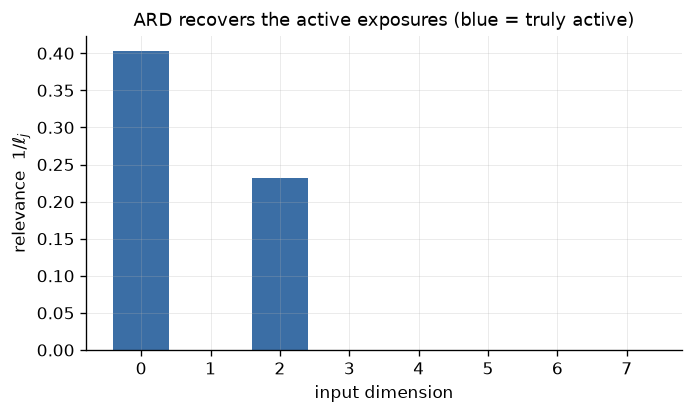

smallest active relevance / largest inactive relevance = 2510.4x separation


In [10]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
cols = [nk.PALETTE["pos"] if j in truly_active else nk.PALETTE["muted"] for j in range(d_ard)]
ax.bar(np.arange(d_ard), 1 / ell_hat, color=cols)
ax.set_xlabel("input dimension"); ax.set_ylabel(r"relevance  $1/\ell_j$")
ax.set_title("ARD recovers the active exposures (blue = truly active)")
plt.show()

rel = 1 / ell_hat
gap = rel[truly_active].min() / np.delete(rel, truly_active).max()
print(f"smallest active relevance / largest inactive relevance = {gap:.1f}x separation")

### Try it 4. Read the relevance plot.

ARD recovered dimensions 0 and 2 with a separation of about 2500× over the irrelevant ones, whose lengthscales ran to $10^4$–$10^5$.

1. Why does a *large* lengthscale mean an *irrelevant* input? Answer in terms of what the kernel does to distances along that axis.
2. Nothing in the code told the model that only two inputs mattered. What did the work?
3. The irrelevant lengthscales differ wildly from each other (10,842 vs 512,947). Is that difference meaningful? What does it tell you about reading precision into these numbers?

**Your answer**

*(write here)*

### Where does ARD break down?

ARD separates cleanly here because the inputs are *independent*. Real exposures are not.
The hard case is not "correlated with an active variable" — ARD handles that fine, since the
true driver still explains the data better. The hard case is **two equally good proxies for
the same latent cause**, which is what co-emitted pollutants actually are.

Here $f$ depends on a latent $u$, and dimensions 0 and 1 are both noisy measurements of $u$.
Neither is "the" right answer, so the marginal likelihood is nearly flat along the direction
trading $\ell_0$ against $\ell_1$. We refit across seeds to see whether the choice is stable.

In [11]:
def make_proxy_data(n=120, d=8, proxy_noise=0.1, seed=0, noise=0.15):
    """dims 0 and 1 are both proxies for a latent u that actually drives f."""
    r = np.random.default_rng(seed)
    X = r.uniform(-2, 2, size=(n, d))
    u = r.uniform(-2, 2, size=n)
    X[:, 0] = u + proxy_noise * r.normal(size=n)
    X[:, 1] = u + proxy_noise * r.normal(size=n)
    f = np.sin(1.6 * u) + 0.7 * X[:, 2]**2
    return X, f - f.mean() + noise * r.normal(size=n)


print("relevance 1/l for the two proxies, across random seeds")
print(f"{'proxy noise':>12} {'seed':>5} {'d0 (proxy)':>11} {'d1 (proxy)':>11} {'d2 (real)':>10}  winner")
for pn in [0.02, 0.5]:
    for sd_ in range(4):
        Xp, yp = make_proxy_data(proxy_noise=pn, seed=sd_)
        rp = minimize(nll_ard, theta0, args=(Xp, yp), method="L-BFGS-B",
                      options=dict(maxiter=800))
        rl = 1 / np.exp(rp.x[:d_ard])
        win = "d0" if rl[0] > rl[1] else "d1"
        print(f"{pn:>12.2f} {sd_:>5} {rl[0]:>11.3f} {rl[1]:>11.3f} {rl[2]:>10.3f}  {win}")
    print()

relevance 1/l for the two proxies, across random seeds
 proxy noise  seed  d0 (proxy)  d1 (proxy)  d2 (real)  winner


        0.02     0       0.000       0.400      0.230  d1


        0.02     1       0.493       0.000      0.321  d0
        0.02     2       0.107       0.372      0.216  d1


        0.02     3       0.396       0.002      0.231  d0

        0.50     0       0.268       0.465      0.418  d1


        0.50     1       0.350       0.322      0.448  d0
        0.50     2       0.401       0.522      0.720  d1


        0.50     3       0.468       0.339      0.513  d0



When the proxies are nearly identical (`proxy noise = 0.02`) the winner flips from seed to
seed and the loser is driven to ~zero relevance: ARD reports a *confident, arbitrary* choice
between two exchangeable variables. When the proxies are noisier and therefore genuinely
distinguishable (`0.5`), the split is more stable.

This is an identifiability limit of the design, not a failure of inference — no method can
tell co-emitted pollutants apart from the outcome alone. What differs between methods is
whether they *admit* it. ARD does not: it hands you one lengthscale per input with no
indication that a different run would pick the other. Part 5's spike-and-slab (5.3) and
projection predictive selection (5.2) address exactly this by putting a posterior over
*which* variables are in the model, so the ambiguity shows up as posterior uncertainty
rather than an arbitrary point estimate.

### Try it 5. The answer flips with the seed. Now what?

With two near-identical proxies for the same latent cause, the winner changed from seed to seed and the loser was driven to ~zero relevance.

1. Explain why this is a property of the **design**, not a bug in the optimiser.
2. ARD reports one number per input and no uncertainty. What would you have to report instead to be honest about this situation?
3. Two co-emitted pollutants behave exactly like these proxies. What does that mean for a paper that claims "PM$_{2.5}$, not NO$_2$, drives the effect"?
4. NB-5 §5.3 fixes this by putting a posterior over *which* variables are in the model. Predict what that output would look like for these two proxies.

**Your answer**

*(write here)*

---
## 2.4 How do we choose hyperparameters without cross-validation?

Integrate out $f$ analytically and you get the **log marginal likelihood** of the
hyperparameters $\theta$:

$$
\log p(y\mid X,\theta) = \underbrace{-\tfrac12 y^\top K_y^{-1} y}_{\text{data fit}}
\;\underbrace{-\;\tfrac12\log\lvert K_y\rvert}_{\text{complexity penalty}}
\;-\;\tfrac{n}{2}\log 2\pi,
\qquad K_y = K_{XX} + \sigma_n^2 I .
$$

Maximising this is **Type-II MLE** (or "empirical Bayes"). The second term is what makes it
work: it is $-\tfrac12\sum\log\lambda_i$, which penalises kernels flexible enough to explain
anything. Occam's razor arrives automatically rather than by a tuning parameter — no
cross-validation loop required.

The gradient uses the cyclic trace identity from §0.3:

$$
\frac{\partial}{\partial\theta_j}\log p(y\mid X,\theta)
= \tfrac12\operatorname{tr}\!\Big[\big(\alpha\alpha^\top - K_y^{-1}\big)\frac{\partial K_y}{\partial\theta_j}\Big],
\qquad \alpha = K_y^{-1}y .
$$

In [12]:
def gp_lml(log_theta, X, y):
    """log p(y|X,theta) with theta = (lengthscale, sigma_f, sigma_n), all logged."""
    ell, sf, sn = np.exp(log_theta)
    K = nk.rbf_kernel(X, X, lengthscale=ell, variance=sf**2) + (sn**2 + 1e-10) * np.eye(len(X))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return -1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return float(-0.5 * y @ a - np.log(np.diag(L)).sum() - 0.5 * len(y) * np.log(2 * np.pi))


def gp_lml_grad(log_theta, X, y):
    """Analytic gradient wrt log-hyperparameters, via tr[(aa' - Ky^-1) dK/dtheta]."""
    ell, sf, sn = np.exp(log_theta)
    D2 = np.sum(X**2, 1)[:, None] + np.sum(X**2, 1)[None, :] - 2 * X @ X.T
    D2 = np.maximum(D2, 0.0)
    Kf = sf**2 * np.exp(-0.5 * D2 / ell**2)
    Ky = Kf + (sn**2 + 1e-10) * np.eye(len(X))

    L = np.linalg.cholesky(Ky)
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    Kinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(len(X))))
    W = np.outer(a, a) - Kinv                        # the common factor

    dK_dlogell = Kf * (D2 / ell**2)                  # chain rule already applied
    dK_dlogsf = 2 * Kf
    dK_dlogsn = 2 * sn**2 * np.eye(len(X))
    return np.array([0.5 * np.sum(W * dK) for dK in (dK_dlogell, dK_dlogsf, dK_dlogsn)])


# Always check the gradient before trusting an optimiser (habit from 0.4).
th = np.log([1.3, 0.9, 0.25])
num = np.array([(gp_lml(th + e, X_tr, y_tr - y_tr.mean())
                 - gp_lml(th - e, X_tr, y_tr - y_tr.mean())) / 2e-6
                for e in 1e-6 * np.eye(3)])
ana = gp_lml_grad(th, X_tr, y_tr - y_tr.mean())
print("analytic grad :", ana)
print("numeric  grad :", num)
print("max abs diff  :", np.abs(ana - num).max())

analytic grad : [-9.0607  3.7909 -9.3335]
numeric  grad : [-9.0607  3.7909 -9.3335]
max abs diff  : 9.434462988622272e-09


In [13]:
yc_tr = y_tr - y_tr.mean()
obj = lambda t: (-gp_lml(t, X_tr, yc_tr), -gp_lml_grad(t, X_tr, yc_tr))

best = None
for start in [np.log([0.2, 0.5, 0.5]), np.log([1.0, 1.0, 0.1]), np.log([5.0, 2.0, 1.0])]:
    r_ = minimize(obj, start, jac=True, method="L-BFGS-B")
    if best is None or r_.fun < best.fun:
        best = r_

ell_ml, sf_ml, sn_ml = np.exp(best.x)
print(f"Type-II MLE:  lengthscale {ell_ml:.4f}   sigma_f {sf_ml:.4f}   sigma_n {sn_ml:.4f}")
print(f"true noise used to generate data: {sigma_n}")
print(f"log marginal likelihood: {-best.fun:.4f}")

# How well is the noise recovered as n grows? Type-II MLE gives a point estimate with no
# error bars, and at small n it is a noisy one -- worth knowing before quoting sigma_n
# from a small cohort as if it were measured.
print()
print(f"{'n':>6} {'ell_hat':>9} {'sigma_n hat':>12}   (truth: sigma_n = 0.20)")
for n_ in [15, 30, 60, 120, 250]:
    Xn_ = np.sort(rng.uniform(-4, 4, n_))[:, None]
    yn_ = f_true(Xn_).ravel() + sigma_n * rng.normal(size=n_)
    yn_c = yn_ - yn_.mean()
    bb = None
    for st in [np.log([0.5, 1.0, 0.3]), np.log([2.0, 1.0, 0.1])]:
        rr = minimize(lambda t: (-gp_lml(t, Xn_, yn_c), -gp_lml_grad(t, Xn_, yn_c)),
                      st, jac=True, method="L-BFGS-B")
        if bb is None or rr.fun < bb.fun:
            bb = rr
    pe = np.exp(bb.x)
    print(f"{n_:>6} {pe[0]:>9.3f} {pe[2]:>12.3f}")

Type-II MLE:  lengthscale 1.0826   sigma_f 0.9581   sigma_n 0.1552
true noise used to generate data: 0.2
log marginal likelihood: -5.6002

     n   ell_hat  sigma_n hat   (truth: sigma_n = 0.20)
    15     1.088        0.275
    30     1.023        0.184
    60     1.165        0.239
   120     1.253        0.207


   250     1.573        0.182


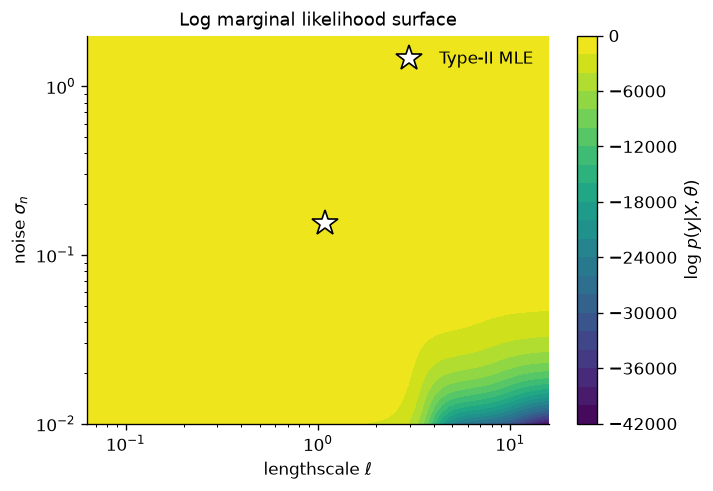

In [14]:
# The marginal likelihood surface, and the fits at three points on it.
ells = np.logspace(-1.2, 1.2, 70)
sns_ = np.logspace(-2, 0.3, 70)
Lsurf = np.array([[gp_lml(np.log([e, sf_ml, s]), X_tr, yc_tr) for e in ells] for s in sns_])

fig, ax = plt.subplots(figsize=(6.2, 4.2))
cs = ax.contourf(ells, sns_, Lsurf, levels=25, cmap="viridis")
ax.plot(ell_ml, sn_ml, "*", color="w", ms=16, mec="k", label="Type-II MLE")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"lengthscale $\ell$"); ax.set_ylabel(r"noise $\sigma_n$")
ax.set_title("Log marginal likelihood surface"); ax.legend()
ax.grid(False); plt.colorbar(cs, ax=ax, label="log $p(y|X,\\theta)$")
plt.show()

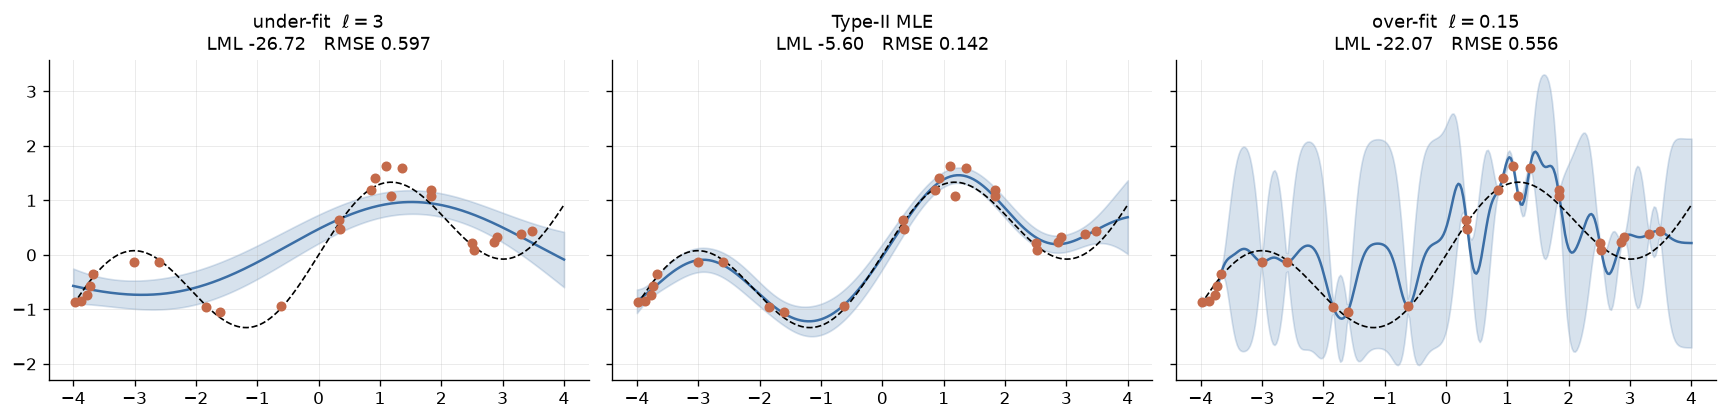

In [15]:
# Underfit / just right / overfit, judged by the marginal likelihood alone.
fits = [("under-fit  $\\ell=3$",   3.0,    0.35),
        ("Type-II MLE",          ell_ml, sn_ml),
        ("over-fit  $\\ell=0.15$", 0.15,   0.02)]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6), sharey=True)
for ax, (name, e, s) in zip(axes, fits):
    g = GP(nk.rbf_kernel, noise=s, lengthscale=e, variance=sf_ml**2).fit(X_tr, y_tr)
    m_, v_ = g.predict(xs)
    sdv = np.sqrt(v_)
    ax.fill_between(xs.ravel(), m_ - 2*sdv, m_ + 2*sdv, alpha=0.2, color=nk.PALETTE["band"])
    ax.plot(xs, m_, color=nk.PALETTE["pos"])
    ax.plot(xs, f_true(xs), "--", color="k", lw=1)
    ax.plot(X_tr, y_tr, "o", color=nk.PALETTE["neg"], ms=5)
    rmse = np.sqrt(np.mean((m_ - f_true(xs).ravel())**2))
    ax.set_title(f"{name}\nLML {g.log_marginal_likelihood():+.2f}   RMSE {rmse:.3f}")
plt.tight_layout(); plt.show()

The marginal likelihood ranks these correctly *without ever seeing the truth*. The
over-fitting kernel reproduces every observation exactly, yet its LML is worst — the
$\log\lvert K_y\rvert$ term charges it for the flexibility. That automatic penalty is the
main practical reason to prefer GPs over kernel ridge regression with a CV-tuned $\lambda$.

### Try it 6. Why does the marginal likelihood not just prefer the wiggliest fit?

The over-fitting kernel reproduced every observation almost exactly and still scored the *worst* log marginal likelihood.

1. Which of the two terms in $\log p(y\mid X,\theta)$ punished it, and what is that term measuring?
2. Contrast this with training MSE. Why would MSE have chosen the wrong model?
3. The noise $\sigma_n$ was recovered as 0.155 against a true 0.20, and the $n$-sweep showed it settling only slowly. What should you *not* claim about a hyperparameter fitted this way on a small cohort?
4. This is the same Occam penalty that appears as $\log|K_y|$. Where did you meet that quantity in NB-0, and why did we insist on computing it via Cholesky?

**Your answer**

*(write here)*

---
## 2.5 What do we do when $n$ is too large?

Exact GPs are $O(n^3)$ time and $O(n^2)$ memory. At $n = 10{,}000$ the Cholesky alone is
~$10^{12}$ flops. **Inducing points** compress the data into $m \ll n$ pseudo-observations
$(Z, u)$ and assume $f$ and $f_*$ are conditionally independent given $u$.

The **Deterministic Training Conditional / Nyström** approximation replaces $K_{XX}$ by

$$
Q_{XX} = K_{XZ}K_{ZZ}^{-1}K_{ZX}
$$

(a rank-$m$ matrix). Woodbury then gives predictions in $O(nm^2)$ instead of $O(n^3)$. We
implement the numerically stable **FITC/DTC** form: never invert $K_{ZZ}$ directly, factor it.

Titsias' variational bound tells us where to *put* the inducing points: maximise

$$
\mathcal{F} = \log\mathcal{N}(y \mid 0, Q_{XX} + \sigma_n^2 I)
- \tfrac{1}{2\sigma_n^2}\operatorname{tr}(K_{XX} - Q_{XX}),
$$

whose trace term penalises placements that fail to explain the data — it is a genuine lower
bound on the exact log marginal likelihood, so it can be compared against it.

In [16]:
class SparseGP:
    """DTC / Titsias sparse GP. O(n m^2) instead of O(n^3)."""

    def __init__(self, kernel, Z, noise=0.1, **kw):
        self.kernel, self.Z, self.noise, self.kw = kernel, np.atleast_2d(Z), noise, kw

    def fit(self, X, y):
        X = np.atleast_2d(X)
        self.X_, self.y_mean_ = X, y.mean()
        yc = y - self.y_mean_
        s2 = self.noise**2

        Kzz = nk.gram(self.kernel, self.Z, **self.kw)
        Kzx = self.kernel(self.Z, X, **self.kw)                     # (m, n)
        Lz, _ = nk.jitter_chol(Kzz)

        A = np.linalg.solve(Lz, Kzx)                                # (m, n); A'A = Q_xx
        B = np.eye(len(self.Z)) + A @ A.T / s2                      # Woodbury core
        LB = np.linalg.cholesky(B)
        self.Lz_, self.LB_, self.A_ = Lz, LB, A

        c = np.linalg.solve(LB, A @ yc) / s2
        self.c_, self.yc_ = c, yc

        # Titsias lower bound on the exact log marginal likelihood
        n = len(X)
        fit_term = -0.5 * (yc @ yc) / s2 + 0.5 * (c @ c)
        logdet = np.log(np.diag(LB)).sum() + 0.5 * n * np.log(s2)
        kdiag = np.diag(nk.gram(self.kernel, X, **self.kw)).sum()
        trace_term = -0.5 * (kdiag - np.sum(A**2)) / s2
        self.elbo_ = float(fit_term - logdet - 0.5 * n * np.log(2 * np.pi) + trace_term)
        self.trace_gap_ = float(kdiag - np.sum(A**2))
        return self

    def predict(self, Xs):
        Xs = np.atleast_2d(Xs)
        Kzs = self.kernel(self.Z, Xs, **self.kw)
        As = np.linalg.solve(self.Lz_, Kzs)                          # (m, m_test)
        mu = As.T @ np.linalg.solve(self.LB_.T, self.c_) + self.y_mean_
        Kss_diag = np.diag(self.kernel(Xs, Xs, **self.kw)).copy()
        v = np.linalg.solve(self.LB_, As)
        var = Kss_diag - np.sum(As**2, 0) + np.sum(v**2, 0)
        return mu, np.maximum(var, 0.0)

In [17]:
# Bigger problem where the O(n^3) cost is real.
n_big = 4000
X_big = np.sort(rng.uniform(-6, 6, n_big))[:, None]
y_big = (np.sin(1.2 * X_big).ravel() + 0.4 * np.cos(3 * X_big).ravel()
         + 0.25 * rng.normal(size=n_big))
xs_big = np.linspace(-6, 6, 400)[:, None]
kw_big = dict(lengthscale=0.7, variance=1.0)

import time
t0 = time.perf_counter()
gp_full = GP(nk.rbf_kernel, noise=0.25, **kw_big).fit(X_big, y_big)
mu_full, var_full = gp_full.predict(xs_big)
t_full = time.perf_counter() - t0
lml_full = gp_full.log_marginal_likelihood()

print(f"exact GP   n={n_big}: {t_full*1000:7.1f} ms   LML {lml_full:10.2f}")
print(f"{'m':>5} {'time (ms)':>10} {'ELBO':>12} {'gap to LML':>12} {'tr(K-Q)':>10} {'pred RMSE':>10}")
for m in [5, 10, 25, 50, 100, 200, 400]:
    Zm = np.linspace(-6, 6, m)[:, None]
    t0 = time.perf_counter()
    sgp = SparseGP(nk.rbf_kernel, Zm, noise=0.25, **kw_big).fit(X_big, y_big)
    mu_s, var_s = sgp.predict(xs_big)
    t_s = (time.perf_counter() - t0) * 1000
    rmse = np.sqrt(np.mean((mu_s - mu_full)**2))
    print(f"{m:>5} {t_s:>10.1f} {sgp.elbo_:>12.2f} {sgp.elbo_ - lml_full:>12.2f} "
          f"{sgp.trace_gap_:>10.2f} {rmse:>10.4f}")

exact GP   n=4000:  2234.4 ms   LML    -231.55
    m  time (ms)         ELBO   gap to LML    tr(K-Q)  pred RMSE
    5      193.4    -34948.62    -34717.07    2395.82     0.6948


   10      158.5     -7162.44     -6930.89     580.86     0.2712
   25      155.9      -233.50        -1.95       0.25     0.0028


   50      157.3      -231.55        -0.00       0.00     0.0000
  100      159.8      -231.55        -0.00       0.00     0.0000


  200      171.8      -231.55        -0.00       0.00     0.0000
  400      197.6      -231.55        -0.00       0.00     0.0000


The ELBO increases monotonically toward the exact LML and the gap is never positive — it is
a genuine lower bound, exactly as the theory promises. The trace term $\operatorname{tr}(K-Q)$
shrinks toward zero as the inducing set becomes sufficient. **This gives a principled way to
choose $m$: increase it until the ELBO stops improving**, with no held-out data needed.

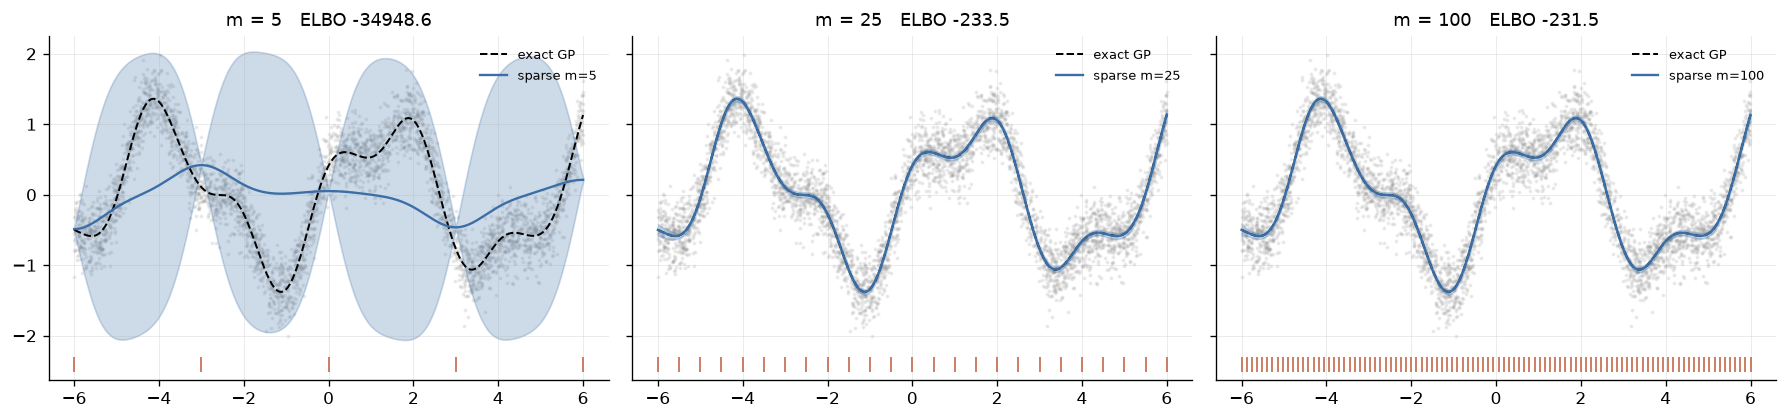

Tick marks along the bottom are the inducing-point locations Z.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, m in zip(axes, [5, 25, 100]):
    Zm = np.linspace(-6, 6, m)[:, None]
    sgp = SparseGP(nk.rbf_kernel, Zm, noise=0.25, **kw_big).fit(X_big, y_big)
    mu_s, var_s = sgp.predict(xs_big)
    sd_s = np.sqrt(var_s)
    ax.scatter(X_big, y_big, s=2, alpha=0.12, color=nk.PALETTE["muted"])
    ax.fill_between(xs_big.ravel(), mu_s - 2*sd_s, mu_s + 2*sd_s, alpha=0.25,
                    color=nk.PALETTE["band"])
    ax.plot(xs_big, mu_full, "--", color="k", lw=1.2, label="exact GP")
    ax.plot(xs_big, mu_s, color=nk.PALETTE["pos"], lw=1.4, label=f"sparse m={m}")
    ax.plot(Zm, np.full(m, y_big.min() - 0.4), "|", color=nk.PALETTE["neg"], ms=9)
    ax.set_title(f"m = {m}   ELBO {sgp.elbo_:.1f}")
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()
print("Tick marks along the bottom are the inducing-point locations Z.")

With $m=5$ the posterior mean is flattened almost to zero — five basis functions cannot
represent a function with this much structure. Note what the uncertainty does: the band
**balloons** rather than shrinking. That is the DTC/Titsias bound behaving well. The trace
penalty $\operatorname{tr}(K-Q)$ is large, the model knows the inducing set cannot explain
the data, and it says so. By $m=25$ the ELBO is within 2 nats of the exact LML and the
curves are visually identical, at roughly $13\times$ the speed.

The honest caveat: this is the *variational* approximation's behaviour. Plain DTC without
the trace correction is famous for the opposite failure — shrinking its variance while the
mean is wrong. If you implement a sparse GP from a paper, check which objective it
optimises before trusting its error bars.

### Try it 7. How many inducing points is enough?

The ELBO rose monotonically toward the exact LML, the gap was never positive, and $\operatorname{tr}(K - Q)$ fell to 0.00 by $m = 50$.

1. Why does the ELBO being a genuine *lower bound* give you a stopping rule that needs no held-out data?
2. At $m = 5$ the credible band ballooned rather than shrinking. Explain why that is the *good* failure mode, and what the bad one would look like.
3. The trace term is the total variance the inducing set fails to explain. If it is large, which would you change first — more inducing points, or different ones? Why?
4. NB-7 §7.1 scales the same problem a different way, by approximating the kernel rather than the posterior. Before reading it, guess one advantage each approach has.

**Your answer**

*(write here)*

## What can we conclude?

A Gaussian process is the conditioning formula from NB-0 §0.6 with the covariance supplied by a kernel. Everything else in this notebook is engineering around that one equation: doing it stably, choosing the kernel's parameters, and doing it faster when $n$ is large.

| What we established | Where it is used next |
|---|---|
| The conditioning formula, implemented stably | reused verbatim in NB-6 for lag models, BKMR, and causal contrasts |
| **ARD**, and its failure on exchangeable proxies | exactly the motivation for spike-and-slab in NB-5 §5.3 |
| Marginal likelihood as an objective with a built-in Occam penalty | the objective optimised throughout NB-4 |
| Analytic gradients, checked before use | NB-7 §7.3, where they make HMC affordable |
| Inducing points and a variational bound | one of the two scaling routes; NB-7 §7.1 is the other |

The honest summary of the limitations: a GP gives you a posterior, not the truth. Its hyperparameters are point estimates here, its ARD relevances can be arbitrary when exposures are collinear, and its credible bands are only as good as the kernel you chose. NB-4 and NB-5 address those in turn.

## What should you submit?

- Run every code cell from top to bottom.
- Write something in your own words in **Try it 1–7**, including the two predict-before-running questions.
- Change a lengthscale, a noise level, or $m$, and record what happened.
- Write down, without looking, what the two terms of the log marginal likelihood do.

**Going further (optional)**

1. Add analytic ARD gradients to `nll_ard` (it currently uses finite differences) and time the speed-up at $d = 50$.
2. Implement the **FITC** correction — replace $Q_{XX}$'s diagonal with the exact $\operatorname{diag}(K_{XX})$ — and see what it does at $m = 5$.
3. Optimise the inducing locations $Z$ by maximising the ELBO instead of fixing them on a grid. Do they migrate toward where the function varies fastest?
4. Swap the RBF for Matérn 5/2 in §2.4 and compare marginal likelihoods. Does the preference survive regenerating the data with a new seed?
5. Show that as $\sigma_n \to 0$ the posterior mean interpolates the observations exactly, and explain via NB-0 §0.2 why the computation becomes unstable there.

*NB-3 stops assuming $x \in \mathbb{R}^d$ with one RBF, and builds kernels that match the structure exposure data actually has.*